### **1. Introduction**

This notebook presents an explainable analysis of soil zones generated using K-Means clustering which is an unsupervised learning method. Since clustering does not involve target labels or predictive objectives, interpretability cannot be achieved through conventional model coefficients or feature weights. Instead, explainability is established through a combination of intrinsic cluster analysis and post-hoc surrogate modeling, following principles from Explainable Artificial Intelligence (XAI).

The primary goal of this work is not to predict soil classes, but to understand and communicate what defines each soil zone, validate their internal consistency, and assess whether the discovered clusters correspond to meaningful and separable soil characteristics.

To achieve this, a hierarchical explainability strategy is adopted:

1. **Intrinsic cluster characterization** is performed using centroid deviation analysis, which directly examines how each cluster differs from the global soil profile across key physical and chemical attributes.

2. A **surrogate Decision Tree classifier** is employed as the primary explainability model to extract human readable decision rules that approximate the cluster boundaries learned by K-Means.

3. A **Random Forest surrogate** is introduced as a secondary, supporting model to validate surrogate fidelity and provide robust global feature importance using SHAP values.

4. Learning curves and validation curves are used to assess model complexity, generalization behaviour, and the stability of surrogate explanations.

In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

import shap

### **2. Load Clustered Dataset**

In [19]:
df = pd.read_csv("../outputs/soil_clusters.csv")

features = [
    "taw", 
    "organic_carbon", 
    "cec", 
    "ph", 
    "sand_pct"
    ]

X = df[features]
y = df["cluster"]

print("Samples:", len(df))
print("Clusters:", sorted(y.unique()))
print("\nCluster distribution:")
print(y.value_counts().sort_index())

Samples: 3422
Clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Cluster distribution:
cluster
0     353
1    1305
2     524
3    1240
Name: count, dtype: int64


### **3. Scale Features for Interpretability**

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)

### **4. Centroid Deviation**

#### **Compute Deviations**

In [21]:
global_mean = X_scaled_df.mean()

cluster_means = X_scaled_df.groupby(y).mean()
deviation = cluster_means - global_mean

deviation

,taw,organic_carbon,cec,ph,sand_pct
cluster,,,,,
0,1.795962,-1.101721,0.428829,0.967773,0.422534
1,-0.599355,-0.600889,-1.201932,-0.355352,-0.122376
2,-0.932307,-0.360482,0.560653,1.589571,1.560045
3,0.513478,1.098355,0.905937,-0.573246,-0.650740


#### **Visualize Cluster Characteristics**

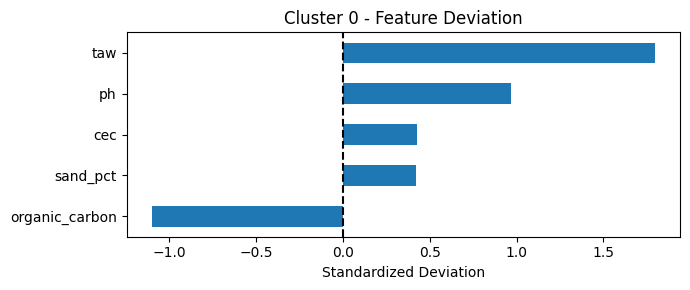

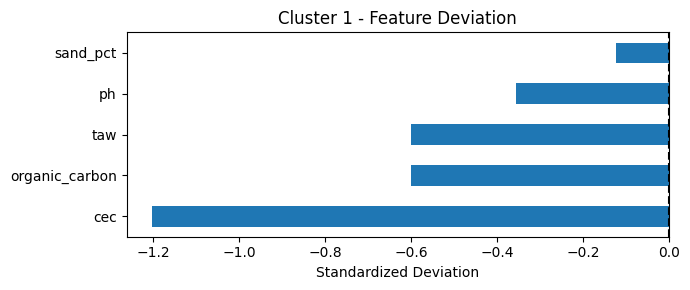

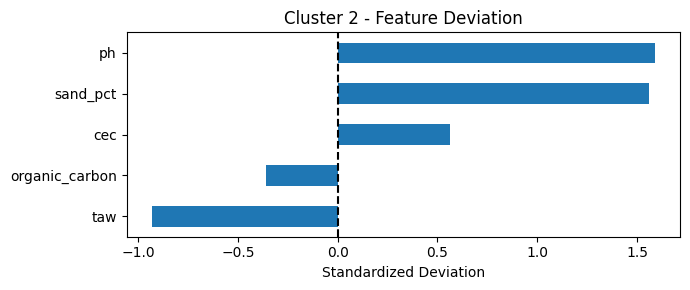

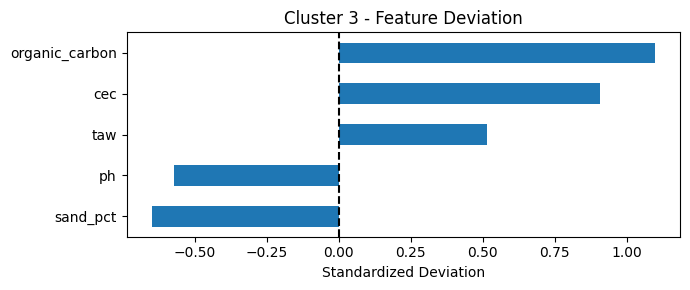

In [22]:
for c in deviation.index:
    plt.figure(figsize=(7, 3))
    deviation.loc[c].sort_values().plot(kind="barh")
    plt.axvline(0, color="black", linestyle="--")
    plt.title(f"Cluster {c} - Feature Deviation")
    plt.xlabel("Standardized Deviation")
    plt.tight_layout()
    plt.show()

The above values represent standardized deviations from the global average soil condition. The magnitude of the absolute value reflects how strongly a given feature characterizes the cluster, with larger absolute values representing more defining soil properties.
$$
\begin{array}{c l}
0 & \text{=  Global average soil} \\
+ & \text{=  Higher than average} \\
- & \text{=  Lower than average}
\end{array}
$$

#### **Cluster 0**
$$
\begin{array}{l c l}
\textbf{Feature} & \textbf{Deviation} & \textbf{Meaning} \\
\hline
\text{TAW} & +1.80 & \text{Extremely high water holding} \\
\text{Organic Carbon} & -1.10 & \text{Very low organic matter} \\
\text{CEC} & +0.43 & \text{Moderate nutrient holding} \\
\text{pH} & +0.97 & \text{Moderately less acidic} \\
\text{Sand \%} & +0.42 & \text{Moderately sandy}
\end{array}
$$

#### **Cluster 1**
$$
\begin{array}{l c l}
\textbf{Feature} & \textbf{Deviation} & \textbf{Meaning} \\
\hline
\text{TAW} & -0.60 & \text{Low water holding} \\
\text{Organic Carbon} & -0.60 & \text{Low organic matter} \\
\text{CEC} & -1.20 & \text{Very poor nutrient holding} \\
\text{pH} & -0.36 & \text{Acidic} \\
\text{Sand \%} & -0.12 & \text{Near average texture}
\end{array}
$$

#### **Cluster 2**
$$
\begin{array}{l c l}
\textbf{Feature} & \textbf{Deviation} & \textbf{Meaning} \\
\hline
\text{TAW} & -0.93 & \text{Very low water holding} \\
\text{Organic Carbon} & -0.36 & \text{Slightly low OC} \\
\text{CEC} & +0.56 & \text{Moderate nutrient holding} \\
\text{pH} & +1.59 & \text{Highest pH} \\
\text{Sand \%} & +1.56 & \text{Extremely sandy}
\end{array}
$$

#### **Cluster 3**
$$
\begin{array}{l c l}
\textbf{Feature} & \textbf{Deviation} & \textbf{Meaning} \\
\hline
\text{TAW} & +0.51 & \text{Good water holding} \\
\text{Organic Carbon} & +1.10 & \text{Very high OC} \\
\text{CEC} & +0.91 & \text{High nutrient holding} \\
\text{pH} & -0.57 & \text{Acidic} \\
\text{Sand \%} & -0.65 & \text{Fine textured}
\end{array}
$$

### **5. Surrogate Decision Tree**

#### **Train Decision Tree Surrogate (Primary Explainer)**

In [23]:
dt = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=50,
    random_state=42
)

dt.fit(X, y)

fidelity = accuracy_score(y, dt.predict(X))
print("Surrogate fidelity:", round(fidelity, 3))

Surrogate fidelity: 0.987


#### **Vizualize Rules**

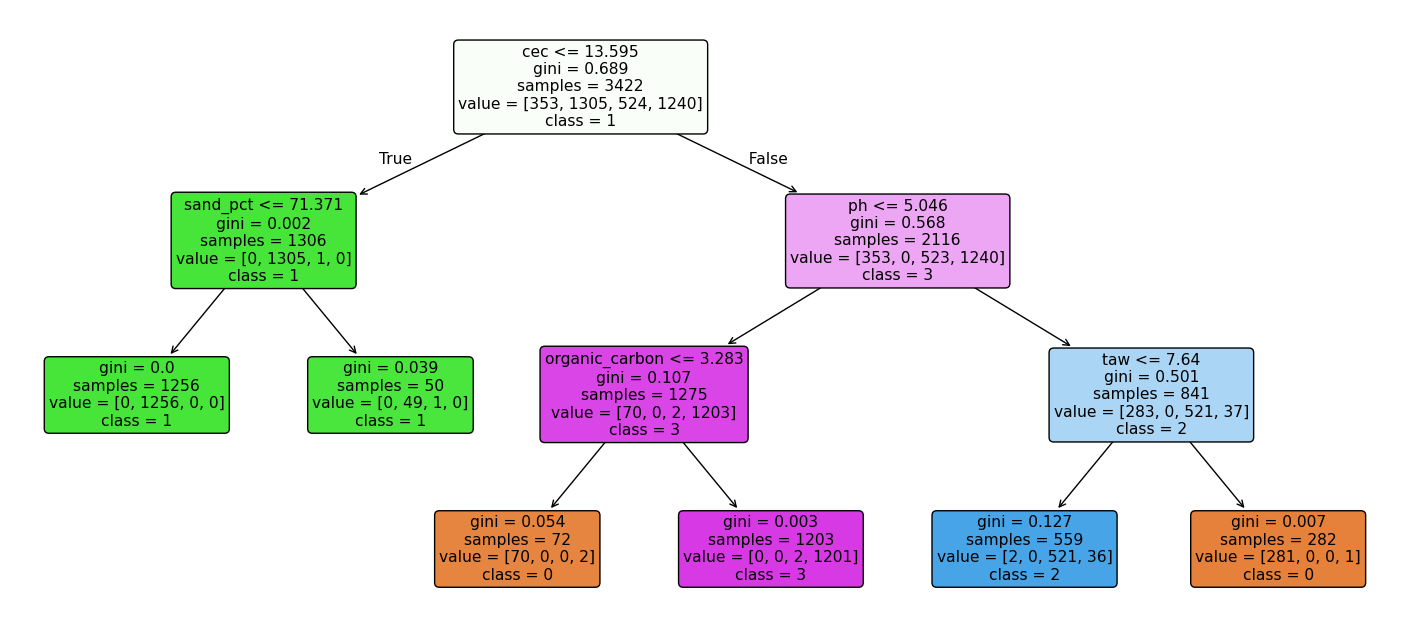

In [24]:
plt.figure(figsize=(18, 8))
plot_tree(
    dt,
    feature_names=features,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True
)
plt.show()

In [25]:
rules = export_text(dt, feature_names=features)
print(rules)

|--- cec <= 13.59
|   |--- sand_pct <= 71.37
|   |   |--- class: 1
|   |--- sand_pct >  71.37
|   |   |--- class: 1
|--- cec >  13.59
|   |--- ph <= 5.05
|   |   |--- organic_carbon <= 3.28
|   |   |   |--- class: 0
|   |   |--- organic_carbon >  3.28
|   |   |   |--- class: 3
|   |--- ph >  5.05
|   |   |--- taw <= 7.64
|   |   |   |--- class: 2
|   |   |--- taw >  7.64
|   |   |   |--- class: 0



In [26]:
# Validate whether Cluster 0 pH-based split is meaningful

cluster_id = 0
threshold = df[df["cluster"] == cluster_id]["ph"].median()

group_low = df[(df["cluster"] == cluster_id) & (df["ph"] <= threshold)]
group_high = df[(df["cluster"] == cluster_id) & (df["ph"] > threshold)]

summary = pd.DataFrame({
    "Low_pH_Subgroup": group_low[features].mean(),
    "High_pH_Subgroup": group_high[features].mean(),
    "Absolute_Difference": (
        group_high[features].mean() - group_low[features].mean()
    ).abs()
})

summary

,Low_pH_Subgroup,High_pH_Subgroup,Absolute_Difference
taw,8.896300,8.753461,0.142839
organic_carbon,3.072083,2.739027,0.333056
cec,17.439899,15.836311,1.603588
ph,5.051771,5.327937,0.276166
sand_pct,66.473359,74.204530,7.731171


Although the surrogate decision tree introduced a split on soil pH prior to final cluster assignment, samples belonging to Cluster 0 appeared on both sides of the pH threshold. This indicated potential conditional heterogeneity within Cluster 0 and motivated further validation. Subgroup means were therefore compared to evaluate whether the pH split represented a meaningful sub zone. The observed pH difference between the two conditional groups $(\approx 0.27)$ was below agronomic relevance thresholds. Although the sand content difference between the two groups was moderate $(\approx 7.7\%)$, sand was not a splitting variable along the Cluster 0 decision paths in the surrogate tree. The observed difference thus reflects a secondary effect induced by splits driven by CEC, pH, and TAW rather than an independent driver of soil zone differentiation. Consequently, the pH-based split was interpreted as decision routing within the surrogate model rather than evidence of a true sub zone.

In [27]:
# Decision Tree - Learning & Validation Curves

from sklearn.model_selection import train_test_split, learning_curve, validation_curve

# Train-Validation Split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

Training samples: 2737
Validation samples: 685


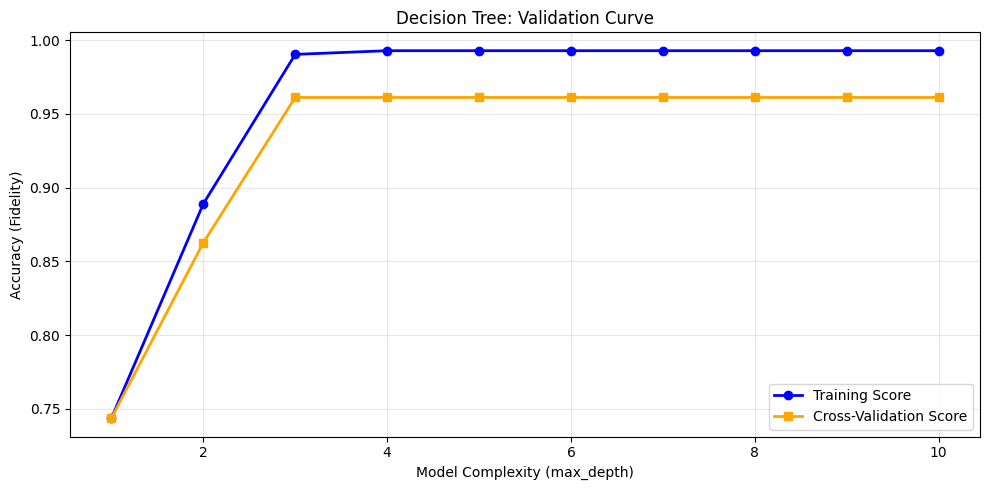


Validation Curve Results:
  Optimal max_depth: 3
  Best CV accuracy: 0.961
  At depth=3: Train=0.990, CV=0.961, Gap=0.029


In [28]:
# Validation Curve

# X-axis: max_depth (model complexity)
# Y-axis: accuracy (performance)

param_range = range(1, 11)

train_scores_val, test_scores_val = validation_curve(
    DecisionTreeClassifier(min_samples_leaf=50, random_state=42),
    X, y,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean_val = np.mean(train_scores_val, axis=1)
train_std_val = np.std(train_scores_val, axis=1)
test_mean_val = np.mean(test_scores_val, axis=1)
test_std_val = np.std(test_scores_val, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(param_range, train_mean_val, marker='o', label='Training Score', linewidth=2, color='blue')
plt.plot(param_range, test_mean_val, marker='s', label='Cross-Validation Score', linewidth=2, color='orange')
plt.xlabel('Model Complexity (max_depth)')
plt.ylabel('Accuracy (Fidelity)')
plt.title('Decision Tree: Validation Curve')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

optimal_depth = param_range[np.argmax(test_mean_val)]
idx_optimal = param_range.index(optimal_depth)

print(f"\nValidation Curve Results:")
print(f"  Optimal max_depth: {optimal_depth}")
print(f"  Best CV accuracy: {max(test_mean_val):.3f}")
print(f"  At depth={optimal_depth}: Train={train_mean_val[idx_optimal]:.3f}, CV={test_mean_val[idx_optimal]:.3f}, Gap={train_mean_val[idx_optimal] - test_mean_val[idx_optimal]:.3f}")

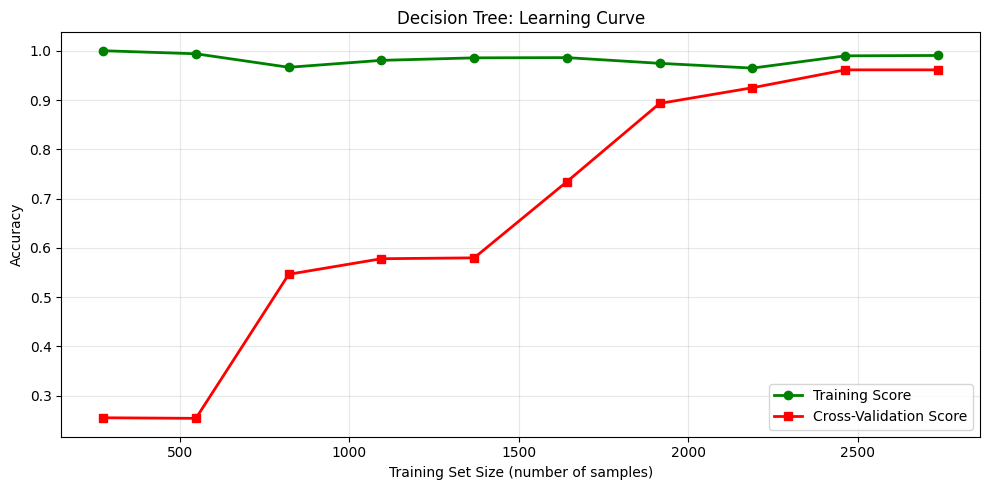


Learning Curve Results:
  Final train score: 0.990 ± 0.005
  Final CV score: 0.961 ± 0.052
  Convergence gap: 0.029
  Good balance: Model generalizes well


In [29]:
# Learning Curve

# X-axis: training set size (number of samples)
# Y-axis: accuracy (performance)

train_sizes, train_scores_learn, test_scores_learn = learning_curve(
    DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=42),
    X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

train_mean_learn = np.mean(train_scores_learn, axis=1)
train_std_learn = np.std(train_scores_learn, axis=1)
test_mean_learn = np.mean(test_scores_learn, axis=1)
test_std_learn = np.std(test_scores_learn, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_mean_learn, marker='o', label='Training Score', linewidth=2, color='green')
plt.plot(train_sizes, test_mean_learn, marker='s', label='Cross-Validation Score', linewidth=2, color='red')
plt.xlabel('Training Set Size (number of samples)')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Learning Curve')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nLearning Curve Results:")
print(f"  Final train score: {train_mean_learn[-1]:.3f} ± {train_std_learn[-1]:.3f}")
print(f"  Final CV score: {test_mean_learn[-1]:.3f} ± {test_std_learn[-1]:.3f}")
print(f"  Convergence gap: {train_mean_learn[-1] - test_mean_learn[-1]:.3f}")

if test_mean_learn[-1] < 0.90:
    print("  High bias: Model too simple")
elif train_mean_learn[-1] - test_mean_learn[-1] > 0.05:
    print("  High variance: Overfitting detected")
else:
    print("  Good balance: Model generalizes well")

### **6. SHAP**

#### **Random Forest (Secondary Explainer)**

In [30]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42
)

rf.fit(X, y)
print("RF surrogate fidelity:", round(accuracy_score(y, rf.predict(X)), 3))

RF surrogate fidelity: 0.996


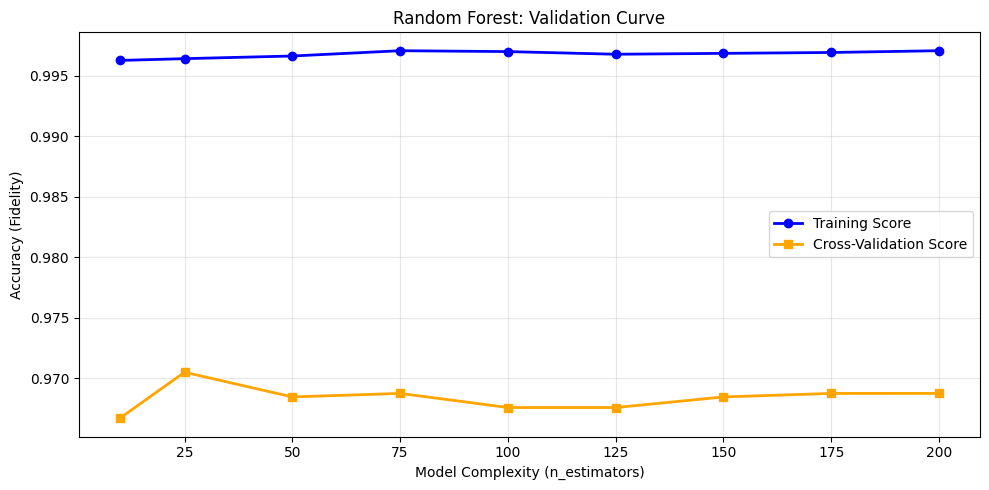


Validation Curve Results:
  Optimal n_estimators: 25
  Best CV accuracy: 0.970
  At n=25: Train=0.996, CV=0.970, Gap=0.026


In [31]:
# Random Forest - Learning & Validation Curves

# Validation Curve

# X-axis: n_estimators (model complexity)
# Y-axis: accuracy (performance)

param_range_rf = [10, 25, 50, 75, 100, 125, 150, 175, 200]

train_scores_val_rf, test_scores_val_rf = validation_curve(
    RandomForestClassifier(max_depth=10, min_samples_leaf=20, random_state=42),
    X, y,
    param_name="n_estimators",
    param_range=param_range_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean_val_rf = np.mean(train_scores_val_rf, axis=1)
train_std_val_rf = np.std(train_scores_val_rf, axis=1)
test_mean_val_rf = np.mean(test_scores_val_rf, axis=1)
test_std_val_rf = np.std(test_scores_val_rf, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(param_range_rf, train_mean_val_rf, marker='o', label='Training Score', linewidth=2, color='blue')
plt.plot(param_range_rf, test_mean_val_rf, marker='s', label='Cross-Validation Score', linewidth=2, color='orange')
plt.xlabel('Model Complexity (n_estimators)')
plt.ylabel('Accuracy (Fidelity)')
plt.title('Random Forest: Validation Curve')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

optimal_n_trees = param_range_rf[np.argmax(test_mean_val_rf)]
idx_optimal = param_range_rf.index(optimal_n_trees)

print(f"\nValidation Curve Results:")
print(f"  Optimal n_estimators: {optimal_n_trees}")
print(f"  Best CV accuracy: {max(test_mean_val_rf):.3f}")
print(f"  At n={optimal_n_trees}: Train={train_mean_val_rf[idx_optimal]:.3f}, CV={test_mean_val_rf[idx_optimal]:.3f}, Gap={train_mean_val_rf[idx_optimal] - test_mean_val_rf[idx_optimal]:.3f}")

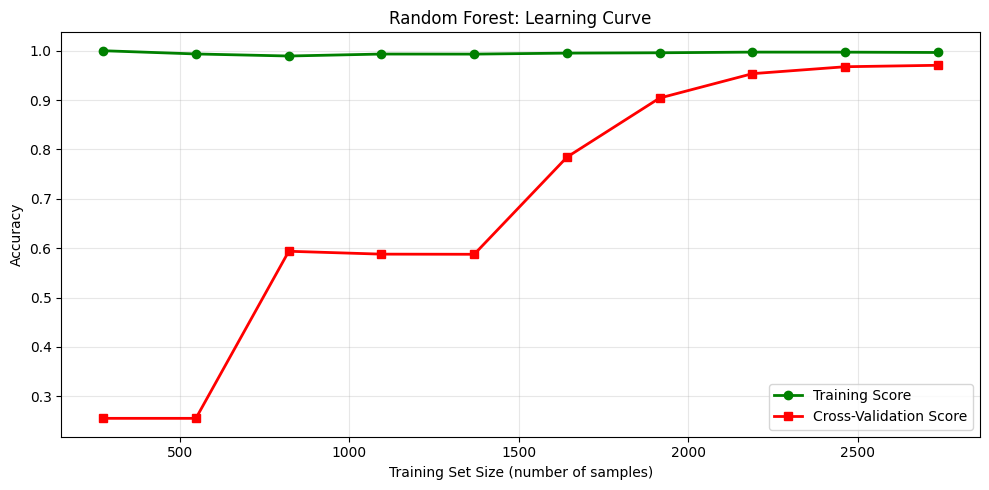


Learning Curve Results:
  Final train score: 0.996 ± 0.002
  Final CV score: 0.970 ± 0.030
  Convergence gap: 0.026
  Good balance: Model generalizes well


In [32]:
# Learning Curve

# X-axis: training set size (number of samples)
# Y-axis: accuracy (performance)

train_sizes_rf, train_scores_learn_rf, test_scores_learn_rf = learning_curve(
    RandomForestClassifier(n_estimators=optimal_n_trees, max_depth=10, min_samples_leaf=20, random_state=42),
    X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

train_mean_learn_rf = np.mean(train_scores_learn_rf, axis=1)
train_std_learn_rf = np.std(train_scores_learn_rf, axis=1)
test_mean_learn_rf = np.mean(test_scores_learn_rf, axis=1)
test_std_learn_rf = np.std(test_scores_learn_rf, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes_rf, train_mean_learn_rf, marker='o', label='Training Score', linewidth=2, color='green')
plt.plot(train_sizes_rf, test_mean_learn_rf, marker='s', label='Cross-Validation Score', linewidth=2, color='red')
plt.xlabel('Training Set Size (number of samples)')
plt.ylabel('Accuracy')
plt.title('Random Forest: Learning Curve')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nLearning Curve Results:")
print(f"  Final train score: {train_mean_learn_rf[-1]:.3f} ± {train_std_learn_rf[-1]:.3f}")
print(f"  Final CV score: {test_mean_learn_rf[-1]:.3f} ± {test_std_learn_rf[-1]:.3f}")
print(f"  Convergence gap: {train_mean_learn_rf[-1] - test_mean_learn_rf[-1]:.3f}")

if test_mean_learn_rf[-1] < 0.90:
    print("  High bias: Model too simple")
elif train_mean_learn_rf[-1] - test_mean_learn_rf[-1] > 0.05:
    print("  High variance: Overfitting detected")
else:
    print("  Good balance: Model generalizes well")

#### **SHAP Global Importance**

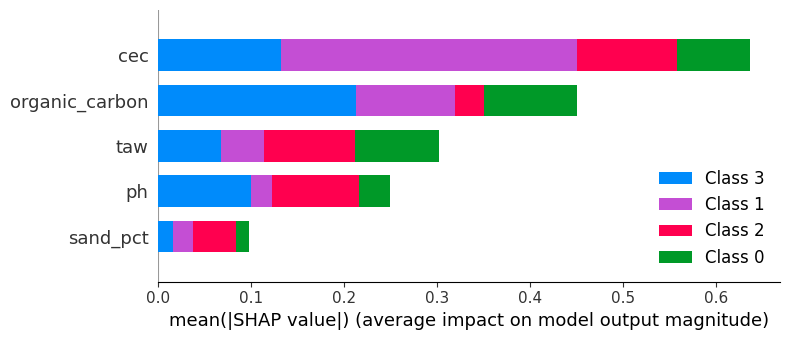

In [33]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

shap.summary_plot(
    shap_values,
    X,
    feature_names=features,
    plot_type="bar"
)

Because K-Means clustering is inherently unsupervised and non parametric, it does not provide explicit decision boundaries or feature level explanations. To bridge this interpretability gap, surrogate models were employed to approximate the cluster assignments using the original soil features. A shallow Decision Tree was selected as the primary surrogate model due to its intrinsic interpretability and ability to express cluster boundaries as human readable rules. The high surrogate fidelity (98.7%) achieved at a low tree depth indicates that the clustering structure can be accurately represented using a small number of dominant soil properties, suggesting well separated and semantically meaningful soil zones.

A Random Forest surrogate was additionally trained as a secondary explanatory model to validate the robustness of the surrogate approximation and to support global feature attribution using SHAP values. Although Random Forests are not intrinsically interpretable, their higher expressive capacity resulted in a marginally higher fidelity (99.6%), confirming that the Decision Tree surrogate does not substantially distort the original clustering logic. Learning curves and validation curves for both surrogate models demonstrated stable convergence and small generalization gaps, indicating that surrogate explanations are not artifacts of overfitting but reflect consistent underlying structure in the clustered data. Together, this hierarchical surrogate framework balances interpretability and fidelity, ensuring that the extracted explanations are both trustworthy and domain relevant.